# Ideitification of new UMI

This notebook profile the threshold of reads number and T-C number for new UMI.

In [1]:
from collections import defaultdict, Counter
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysam

## 1. Test thresholds

In [20]:
# Load metrics
data =dict()

d = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
d = d[(d["Time"] == 3) & (d["ActD"].isna()) & (d["UMIs"] > 5000)]
data["K562.s4U_0uM_180min"] = d[(d["Cell_Type"] == "K562") & (d["s4U"] == 0)]
data["K562.s4U_50uM_180min"] = d[(d["Cell_Type"] == "K562") & (d["s4U"] == 50) & (d["TC.Ratio"] > 0.008) & (d["TC.Ratio"] < 1)]
data["mESC.s4U_0uM_180min"] = d[(d["Cell_Type"] == "mESC") & (d["s4U"] == 0)]
data["mESC.s4U_400uM_180min"] = d[(d["Cell_Type"] == "mESC") & (d["s4U"] == 400) & (d["TC.Ratio"] > 0.01) & (d["TC.Ratio"] < 1)]

for k, v in data.items():
    print(v.shape, k ,sep="\t")

(190, 48)	K562.s4U_0uM_180min
(105, 48)	K562.s4U_50uM_180min
(64, 48)	mESC.s4U_0uM_180min
(110, 48)	mESC.s4U_400uM_180min


In [25]:
def stat_single_cell_new_proportion(path, min_tc):
    counter1 = defaultdict(int)
    counter2 = defaultdict(int)
    d = pd.read_csv(path, sep="\t", index_col=0)
    for size, tc in d[["Size", "T-C"]].values:
        counter1[size] += 1
        if tc >= min_tc:
            counter2[size] += 1
    rows = []
    sizes = np.arange(1, 8)
    for size in sizes:
        c1, c2 = counter1[size], counter2[size]
        rows.append([c1, c2])
    m = pd.DataFrame(rows, index=pd.Index(sizes, name="Size"), columns=["Total", "New"])
    m["New.Perc"] = m["New"] / m["Total"]
    return m
    
def stat_tc_proportion(cells, min_tc, outfile):
    array = []
    for cell in cells:
        path = "../../../1_NanoNASCseq/results/4_mismatch/4_ratio_consensus/%s/%s.events.tsv" % (cell.split(".")[0], cell)
        d = stat_single_cell_new_proportion(path, min_tc)
        if d["Total"].min() < 200:
            continue
        s = d["New.Perc"]
        s.name = cell
        array.append(s)
    m = pd.DataFrame(array)
    m.index.name = "Cell"
    m.to_csv(outfile)

pool = mp.Pool(24)
for name, d in data.items():
    for tc in [1, 2, 3]:
        outfile = "results/new_proportion/%s.%dTC.csv" % (name, tc)
        print("Outfile:", outfile)
        args = (d.index, tc, outfile)
        pool.apply_async(stat_tc_proportion, args)
pool.close()
pool.join()

Outfile: results/new_proportion/K562.s4U_0uM_180min.1TC.csv
Outfile: results/new_proportion/K562.s4U_0uM_180min.2TC.csv
Outfile: results/new_proportion/K562.s4U_0uM_180min.3TC.csv
Outfile: results/new_proportion/K562.s4U_50uM_180min.1TC.csv
Outfile: results/new_proportion/K562.s4U_50uM_180min.2TC.csv
Outfile: results/new_proportion/K562.s4U_50uM_180min.3TC.csv
Outfile: results/new_proportion/mESC.s4U_0uM_180min.1TC.csv
Outfile: results/new_proportion/mESC.s4U_0uM_180min.2TC.csv
Outfile: results/new_proportion/mESC.s4U_0uM_180min.3TC.csv
Outfile: results/new_proportion/mESC.s4U_400uM_180min.1TC.csv
Outfile: results/new_proportion/mESC.s4U_400uM_180min.2TC.csv
Outfile: results/new_proportion/mESC.s4U_400uM_180min.3TC.csv


--------------------------------------------------------------------------------
Cell line: K562
Min TC counts: 1
Cells (control): 156
Cells (treatment): 75
#Size	Control	Treatment
1	46.62	53.7
2	3.37	20.9
3	2.63	19.81
4	3.14	20.22
5	3.15	19.9
6	3.17	19.82
7	3.37	19.12


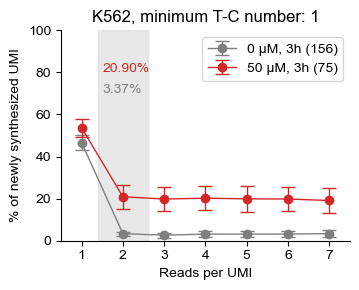

--------------------------------------------------------------------------------
Cell line: K562
Min TC counts: 2
Cells (control): 156
Cells (treatment): 75
#Size	Control	Treatment
1	25.01	36.43
2	0.35	18.1
3	0.27	17.44
4	0.31	17.39
5	0.33	17.06
6	0.33	17.11
7	0.37	16.44


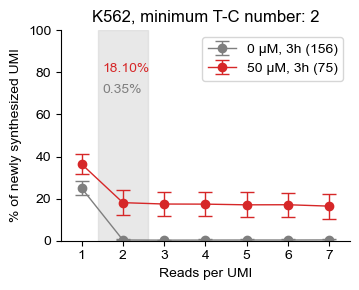

--------------------------------------------------------------------------------
Cell line: K562
Min TC counts: 3
Cells (control): 156
Cells (treatment): 75
#Size	Control	Treatment
1	15.14	28.56
2	0.15	17.56
3	0.14	17.0
4	0.14	16.97
5	0.18	16.71
6	0.19	16.71
7	0.19	16.05


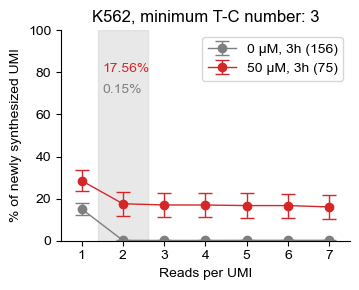

--------------------------------------------------------------------------------
Cell line: mESC
Min TC counts: 1
Cells (control): 58
Cells (treatment): 63
#Size	Control	Treatment
1	46.09	73.87
2	6.25	50.02
3	5.79	50.01
4	6.71	51.38
5	6.96	51.5
6	6.83	52.24
7	6.82	52.53


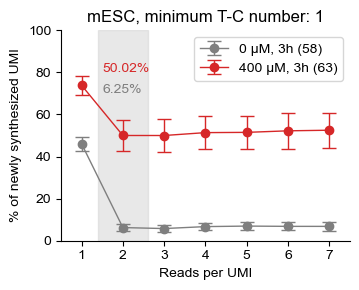

--------------------------------------------------------------------------------
Cell line: mESC
Min TC counts: 2
Cells (control): 58
Cells (treatment): 63
#Size	Control	Treatment
1	24.86	60.78
2	0.7	44.27
3	0.58	44.64
4	0.75	46.66
5	0.72	46.82
6	0.75	47.66
7	0.78	47.9


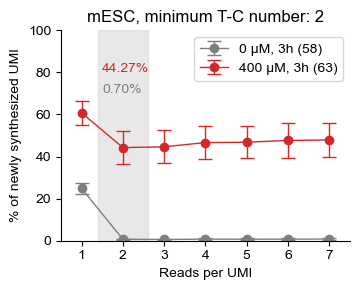

--------------------------------------------------------------------------------
Cell line: mESC
Min TC counts: 3
Cells (control): 58
Cells (treatment): 63
#Size	Control	Treatment
1	15.4	52.28
2	0.25	39.13
3	0.24	39.41
4	0.29	42.54
5	0.26	43.06
6	0.27	43.98
7	0.29	43.94


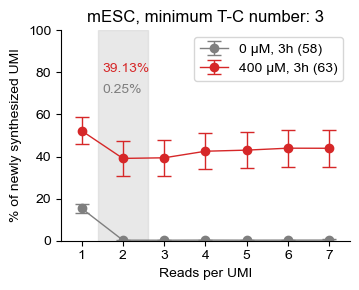

In [52]:
for cell_line in ["K562", "mESC"]:
    for min_tc_count in [1, 2, 3]:
        print("-" * 80)
        print("Cell line:", cell_line)
        print("Min TC counts:", min_tc_count)
        
        if cell_line == "K562":
            s4u = 50
        else:
            s4u = 400
        m1 = pd.read_csv("results/new_proportion/%s.s4U_0uM_180min.%dTC.csv" % (cell_line, min_tc_count), index_col=0) * 100
        m2 = pd.read_csv("results/new_proportion/%s.s4U_%duM_180min.%dTC.csv" % (cell_line, s4u, min_tc_count), index_col=0) * 100
        m1.columns = m1.columns.astype(int)
        m2.columns = m2.columns.astype(int)

        print("Cells (control):", len(m1))
        print("Cells (treatment):", len(m2))
        
        means1 = m1.mean(axis=0)
        stds1 = m1.std(axis=0)
        means2 = m2.mean(axis=0)
        stds2 = m2.std(axis=0)
        xs = m1.columns
        p1, p2 = means1[2], means2[2]

        print("#Size\tControl\tTreatment")
        for x, v1, v2 in zip(xs, means1, means2):
            print(x, round(v1, 2), round(v2, 2), sep="\t")
        
        plt.figure(figsize=(3.7, 3))
        plt.title("%s, minimum T-C number: %d" % (cell_line, min_tc_count))
        plt.errorbar(m1.columns, means1, yerr=stds1, marker="o", color="C7", \
                     capsize=5, lw=1, capthick=1, label="0 μM, 3h (%d)" % len(m1))
        plt.errorbar(m2.columns, means2, yerr=stds2, marker="o", color="C3", \
                     capsize=5, lw=1, capthick=1, label="%d μM, 3h (%d)" % (s4u, len(m2)))
        if True:
            plt.axvspan(2 - 0.6, 2 + 0.6, color="lightgrey", alpha=0.5)
            plt.text(2 - 0.5, 70, "%.2f%%" % p1, color="C7", ha="left")
            plt.text(2 - 0.5, 80, "%.2f%%" % p2, color="C3", ha="left")
        plt.xlim(0.5, 7.5)
        plt.ylim(0, 100)
        plt.xlabel("Reads per UMI")
        plt.ylabel("% of newly synthesized UMI")
        plt.xticks(xs)
        plt.legend()
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.tight_layout()
        plt.savefig("figures/new_rna_proportion.%s.%dTC.pdf" % (cell_line, min_tc_count))
        plt.show()
        plt.close()

## 2. Characters of srUMIs

In [14]:
d = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
d = d[d["UMIs"] >= 5000]
d1 = d[(d["CellLine"] == "K562") & (d["s4U"] == 0) & (d["Time"] == 3) & (d["ActD"].isna())]
d2 = d[(d["CellLine"] == "K562") & (d["s4U"] == 50) & (d["Time"] == 3) & (d["ActD"].isna())]
d2 = d2[d2["TC.Ratio"] >= 0.008]
df1 = d1.head(10)
df2 = d2.head(10)
df_list = [df1, df2]

In [15]:
def stat_tc(bamfile, f_tsv=None):
    umis = None
    if f_tsv:
        tmp = pd.read_csv(f_tsv, sep="\t", header=0, index_col=0)
        umis = set(tmp[(tmp["Size"] >= 2) & (tmp["T-C"] >= 2)].index)
    rows = []
    with pysam.AlignmentFile(bamfile) as f:
        for s in f:
            if s.is_duplicate:
               continue
            if umis is not None and s.get_tag("CN") not in umis:
                continue
            counter1 = defaultdict(int)
            for item in s.get_tag("RC").split(";"):
                if item == "":
                    continue
                k, v = item.split(",")
                counter1[k] = int(v)
            counter2 = defaultdict(int)
            for item in s.get_tag("CE").split(";"):
                if item == "":
                    continue
                tmp = item.split(",")
                ref, alt = tmp[1], tmp[2]
                counter2[(ref, alt)] += 1
            if s.is_forward:
                t = counter1["T"]
                tc = counter2[("T", "C")]
            else:
                t = counter1["A"]
                tc = counter2[("A", "G")]
            rows.append([t, tc])
    # print("Finished %s" % bamfile)
    return rows
data = dict()
pool = mp.Pool(24)
for run, cell in df1[["Run", "Cell"]].values:
    bamfile = "../../../1_NanoNASCseq/results/04_mismatch/01_tagged_events/%s/%s.bam" % (run, cell)
    data[cell] = pool.apply_async(stat_tc, (bamfile,))
for run,cell in df2[["Run", "Cell"]].values:
    bamfile = "../../../1_NanoNASCseq/results/04_mismatch/01_tagged_events/%s/%s.bam" % (run, cell)
    tsvfile = "../../../1_NanoNASCseq/results/04_mismatch/04_ratio_consensus/%s/%s.events.tsv" % (run, cell)
    data[cell] = pool.apply_async(stat_tc, (bamfile, tsvfile))
pool.close()
pool.join()
for cell in data:
    data[cell] = data[cell].get()

In [16]:
max_tc = 10
max_ratio = 10
w = 0.5
labels = ["Old reads", "New reads"]
colors = ["C7", "C3"]

--------------------------------------------------------------------------------
Condition	No. of T-C	Mean	Std	Exists	Nascent
0	0	69.6484	2.419	69.6484	30.3516
0	1	17.9671	1.0644	87.6154	12.3846
0	2	5.6839	0.5023	93.2994	6.7006
0	3	2.661	0.3465	95.9603	4.0397
0	4	1.397	0.2482	97.3573	2.6427
0	5	0.8094	0.1291	98.1667	1.8333
0	6	0.5234	0.073	98.6901	1.3099
0	7	0.3592	0.0936	99.0493	0.9507
0	8	0.2589	0.0384	99.3082	0.6918
0	9	0.1783	0.0465	99.4865	0.5135
0	10	0.1343	0.0467	99.6208	0.3792
--------------------------------------------------------------------------------
Condition	No. of T-C	Mean	Std	Exists	Nascent
1	0	0.0562	0.1098	0.0562	99.9438
1	1	0.0679	0.0919	0.1241	99.8759
1	2	2.731	0.653	2.8551	97.1449
1	3	1.9577	0.7772	4.8128	95.1872
1	4	2.4923	0.4273	7.305	92.695
1	5	2.5021	0.6402	9.8071	90.1929
1	6	2.5621	0.6974	12.3692	87.6308
1	7	2.6958	0.5698	15.065	84.935
1	8	3.328	0.9211	18.393	81.607
1	9	3.0084	0.75	21.4015	78.5985
1	10	3.0425	0.6449	24.444	75.556


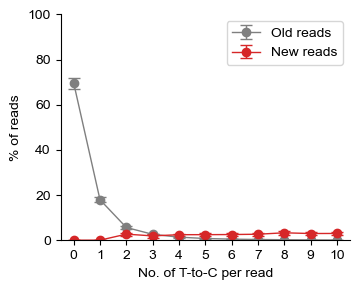

In [17]:
plt.figure(figsize=(3.7, 3))
for i, df in enumerate(df_list):
    rows = []
    for cell in df["Cell"]:
        counter = Counter([row[1] for row in data[cell]])
        vs = [counter[i] for i in range(max_tc + 1)]
        rows.append(np.array(vs) / sum(counter.values()))
    m = pd.DataFrame(rows) * 100
    ys = m.mean(axis=0)
    yerr = m.std(axis=0)
    xs = np.arange(len(ys))
    print("-" * 80)
    print("Condition\tNo. of T-C\tMean\tStd\tExists\tNascent")
    cum = 0
    for x, y, y1 in zip(xs, ys, yerr):
        cum += y
        print(i, x, round(y, 4), round(y1, 4), round(cum, 4), round(100 - cum, 4), sep="\t")
    plt.errorbar(xs, ys, yerr=yerr, label=labels[i], capsize=4, lw=1, marker="o", color=colors[i])
plt.xticks(xs)
plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
plt.ylim(0, 100)
plt.xlabel("No. of T-to-C per read")
plt.ylabel("% of reads")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend()
plt.tight_layout()
plt.savefig("figures/stat_of_tc_count.pdf", dpi=300)

--------------------------------------------------------------------------------
Condition	% of T-C	Mean	Std	Exists	Nascent
0	0	91.8256	0.3977	91.8256	8.1744
0	1	5.9127	0.2916	97.7384	2.2616
0	2	1.5004	0.1147	99.2388	0.7612
0	3	0.5058	0.0366	99.7446	0.2554
0	4	0.1641	0.0228	99.9086	0.0914
0	5	0.0528	0.0117	99.9614	0.0386
0	6	0.0228	0.0079	99.9842	0.0158
0	7	0.0097	0.0066	99.9939	0.0061
0	8	0.0032	0.0042	99.997	0.003
0	9	0.0021	0.0023	99.9992	0.0008
0	10	0.0008	0.0018	100.0	0.0
--------------------------------------------------------------------------------
Condition	% of T-C	Mean	Std	Exists	Nascent
1	0	1.9114	0.6946	1.9114	98.0886
1	1	3.9754	1.0214	5.8868	94.1132
1	2	4.1209	1.1613	10.0077	89.9923
1	3	4.346	1.0546	14.3537	85.6463
1	4	4.2567	1.4196	18.6104	81.3896
1	5	5.0087	1.2006	23.6192	76.3808
1	6	5.705	1.9619	29.3242	70.6758
1	7	5.3073	1.615	34.6315	65.3685
1	8	6.0635	1.9044	40.695	59.305
1	9	5.4519	1.122	46.147	53.853
1	10	6.439	1.3689	52.586	47.414


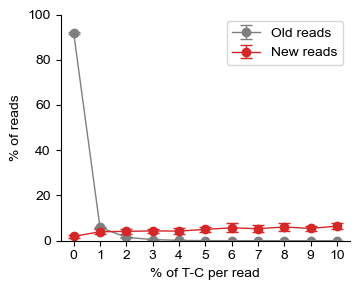

In [18]:
plt.figure(figsize=(3.7, 3))
for i, df in enumerate(ds):
    rows = []
    for cell in df["Cell"]:
        counter = Counter([int(row[1] * 100 / row[0]) for row in data[cell]])
        vs = [counter[i] for i in range(max_ratio + 1)]
        rows.append(np.array(vs) / sum(counter.values()))
    m = pd.DataFrame(rows) * 100
    ys = m.mean(axis=0)
    yerr = m.std(axis=0)
    xs = np.arange(len(ys))
    print("-" * 80)
    print("Condition\t% of T-C\tMean\tStd\tExists\tNascent")
    cum = 0
    for x, y, y1 in zip(xs, ys, yerr):
        cum += y
        print(i, x, round(y, 4), round(y1, 4), round(cum, 4), round(100 - cum, 4), sep="\t")
    plt.errorbar(xs, ys, yerr=yerr, label=labels[i], capsize=4, lw=1, marker="o", color=colors[i])
plt.xticks(xs)
plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
plt.ylim(0, 100)
plt.xlabel("% of T-C per read")
plt.ylabel("% of reads")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend()
plt.tight_layout()
plt.savefig("figures/stat_of_tc_ratio.pdf")